## Pipeline tổng quan
---

1. Import thư viện
2. Load dữ liệu
3. Khám phá dữ liệu
4. Làm sạch dữ liệu
5. Feature creation và feature transformation
6. Xây dựng và so sánh mô hình
7. Đánh giá mô hình
8. Chia dữ liệu train/test chuẩn
9. Lưu model và suy luận
10. Chia dữ liệu cho luồng đánh giá bổ sung
11. Bảng so sánh metric Train/Test
12. Hyperparameter tuning
13. Train Logistic Regression cho luồng đánh giá bổ sung

## 1. Import thư viện
---

In [82]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TARGET_COL = 'Diabetes'

### Nhận xét output

- Các thư viện cốt lõi cho tiền xử lý, modeling và đánh giá đã được import đầy đủ.
- Hằng số random state và target được khai báo từ đầu để dễ quản lý xuyên suốt notebook.
- Đây là nền tảng để các cell phía sau chạy ổn định và tái lập.

## 2. Load dữ liệu
---

In [94]:
candidate_paths = [
    Path('Data_diabetes.csv'),
    Path('DATN_1') / 'Data_diabetes.csv',
    Path.cwd() / 'Data_diabetes.csv',
    Path.cwd() / 'DATN_1' / 'Data_diabetes.csv',
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Khong tim thay Data_diabetes.csv trong thu muc hien tai hoac DATN_1')

BASE_DIR = data_path.resolve().parent
ARTIFACT_DIR = BASE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(data_path, low_memory=False, encoding='latin-1')
print('Data path:', data_path.resolve())
print('Base dir:', BASE_DIR)
print('Shape:', data.shape)
data.head()

Data path: C:\Users\BSS GROUP\DATN_1\Data_diabetes.csv
Base dir: C:\Users\BSS GROUP\DATN_1
Shape: (12725, 75)


,V1,Tinh/Thanhpho,Quan/huyen,Xa/phuong,Ngay phong van,Ho ten,id,Dia chi,Gioi,Nam sinh,Dan toc,Tinh chat cong viec,Trinh do van hoa,Thoi gian an cach bua toi,Tien xu bi tang huyet ap,Nam chuan doan tang huyet ap,Da dieu tri tang huyet ap bao gio chua,Bang an uong va luyen tap,DT_THA_DY,DT_THA_TY,GÐ_CNB_ÐTÐ,Bo/Me_MÐTÐ,Anh/chi/em MDTÐ,Ong/ba noi MÐTÐ,Con_MÐTÐ,tien_xu_benh _tim_mach,dot_quy,Dau_that_nguc,Suy_tim,loet_ban_chan,cat_cut_chi,roi_loan_mo_mau,roi_loan_mo_mau_nam,kg_luc_nang_nhat,tuoi_luc_nang_nhat,da_mang_thai_chua,co_bi_tieu_duong_thai_ki_khong,xet_nghiem_duong_mau_luc_doi,xet_nghiem_duong_mau_sau_2h,year,Nhomtuoi,chieucao_mean,cannang_mean,vongeo_mean,vonghong_mean,HATT_mean,HATTr_mean,BMI,BMI_class,Abdominal_Obese,Hypertension_class,WHR,WHR_male,WHR_female,WHR_class,Diabetes,Pre_diabete,Glucose_class,std_wgt1,cvd,obesity,khuvuc,khuvuc2,WHR_male2,WHR_female2,WHR_total,glucose,prediabetes2,std_wgt3,tccv,glucose2,fpg,dia,predia,fpgva
0,1785,32,1,4,40717.0,DANG THI THU HA,34.0,"TO 1, THACH THANG",2,1950,1,2,5,11,1,2009,2.0,2.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,54,61,1.0,2.0,"5,6","6,8",2011,4,150,54,70,85,120,70,24,3,0,0.0,0.823529411764706,NaN,3.0,3,0,1.0,1,0.108646,0,0,2,2,NaN,1.0,1,1,1,0.119252,0,1,1,0,1,0
1,1565,32,1,1,40733.0,LE THI THANH HUYEN,64.0,"TO 24, THANH BINH",2,1944,1,2,4,12,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,62,66,1.0,2.0,"7,8","16,4",2011,5,"146,05",60,94,102,120,80,28.1286006806418,4,1,1.0,0.92156862745098,NaN,4.0,4,1,NaN,2,0.108646,0,1,2,2,NaN,1.0,1,2,0,0.095826,0,2,2,1,0,0
2,460,32,1,3,40726.0,HA THUC HAI,210.0,"TO 36, BINH HIEN",1,1954,1,2,5,10,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,81,55,2.0,NaN,"5,7","6,1",2011,3,169,81,101,104,140,80,28.3603515283078,4,1,2.0,0.971153846153846,3.0,NaN,3,0,1.0,1,0.178560,0,1,2,2,1.0,NaN,1,1,1,0.183041,0,1,1,0,1,0
3,1990,32,1,4,40721.0,HO THI GIAO,241.0,"TO 30, THACH THANG",2,1942,1,2,4,12,1,2008,2.0,1.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,2.0,2.0,1.0,2.0,2.0,2.0,2,2009,69,69,1.0,2.0,"6,6","10,2",2011,5,152,69,94,107,120,80,29.8649584487535,4,1,1.0,0.878504672897196,NaN,4.0,4,0,1.0,1,0.108646,1,1,2,2,NaN,1.0,1,1,1,0.095826,0,1,1,0,1,0
4,978,32,2,3,40731.0,NGUYEN VAN VIEN,228.0,"TO 35, HOA KHE",1,1965,1,2,3,11,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0,1.0,2.0,2.0,1,9999,53,50,2.0,NaN,"6,2","7,6",2011,1,153,52,75,96,"110,5",70,22.2136784997223,2,0,0.0,"0,78125",1.0,NaN,1,0,1.0,1,0.223166,1,0,2,2,0.0,NaN,0,1,1,0.329838,0,1,1,0,1,0


### Nhận xét output

- Dữ liệu đã được đọc thành công từ file CSV và giữ nguyên cấu trúc ban đầu.
- Kích thước dữ liệu được in ra giúp kiểm tra nhanh số dòng và số cột.
- Bước tiếp theo sẽ đi vào quan sát phân bố nhãn và chất lượng dữ liệu.

## 3. Khám phá dữ liệu
---

### Quan sát và khám phá tập dữ liệu

In [85]:
# Tạo cột Tuổi dựa vào năm thu thập
YEAR_COLLECTED = 2022

if 'Nam sinh' in data.columns:
    data['Tuoi'] = YEAR_COLLECTED - pd.to_numeric(data['Nam sinh'], errors='coerce')
    data = data.drop(columns=['Nam sinh'])

print('Đã tạo cột Tuổi và loại bỏ Nam sinh (nếu có).')
print('Shape hiện tại:', data.shape)
data.head()

Đã tạo cột Tuổi và loại bỏ Nam sinh (nếu có).
Shape hiện tại: (12725, 75)


,V1,Tinh/Thanhpho,Quan/huyen,Xa/phuong,Ngay phong van,Ho ten,id,Dia chi,Gioi,Dan toc,Tinh chat cong viec,Trinh do van hoa,Thoi gian an cach bua toi,Tien xu bi tang huyet ap,Nam chuan doan tang huyet ap,Da dieu tri tang huyet ap bao gio chua,Bang an uong va luyen tap,DT_THA_DY,DT_THA_TY,GÐ_CNB_ÐTÐ,Bo/Me_MÐTÐ,Anh/chi/em MDTÐ,Ong/ba noi MÐTÐ,Con_MÐTÐ,tien_xu_benh _tim_mach,dot_quy,Dau_that_nguc,Suy_tim,loet_ban_chan,cat_cut_chi,roi_loan_mo_mau,roi_loan_mo_mau_nam,kg_luc_nang_nhat,tuoi_luc_nang_nhat,da_mang_thai_chua,co_bi_tieu_duong_thai_ki_khong,xet_nghiem_duong_mau_luc_doi,xet_nghiem_duong_mau_sau_2h,year,Nhomtuoi,chieucao_mean,cannang_mean,vongeo_mean,vonghong_mean,HATT_mean,HATTr_mean,BMI,BMI_class,Abdominal_Obese,Hypertension_class,WHR,WHR_male,WHR_female,WHR_class,Diabetes,Pre_diabete,Glucose_class,std_wgt1,cvd,obesity,khuvuc,khuvuc2,WHR_male2,WHR_female2,WHR_total,glucose,prediabetes2,std_wgt3,tccv,glucose2,fpg,dia,predia,fpgva,Tuoi
0,1785,32,1,4,40717.0,DANG THI THU HA,34.0,"TO 1, THACH THANG",2,1,2,5,11,1,2009,2.0,2.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,54,61,1.0,2.0,"5,6","6,8",2011,4,150,54,70,85,120,70,24,3,0,0.0,0.823529411764706,NaN,3.0,3,0,1.0,1,0.108646,0,0,2,2,NaN,1.0,1,1,1,0.119252,0,1,1,0,1,0,72
1,1565,32,1,1,40733.0,LE THI THANH HUYEN,64.0,"TO 24, THANH BINH",2,1,2,4,12,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,62,66,1.0,2.0,"7,8","16,4",2011,5,"146,05",60,94,102,120,80,28.1286006806418,4,1,1.0,0.92156862745098,NaN,4.0,4,1,NaN,2,0.108646,0,1,2,2,NaN,1.0,1,2,0,0.095826,0,2,2,1,0,0,78
2,460,32,1,3,40726.0,HA THUC HAI,210.0,"TO 36, BINH HIEN",1,1,2,5,10,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,81,55,2.0,NaN,"5,7","6,1",2011,3,169,81,101,104,140,80,28.3603515283078,4,1,2.0,0.971153846153846,3.0,NaN,3,0,1.0,1,0.178560,0,1,2,2,1.0,NaN,1,1,1,0.183041,0,1,1,0,1,0,68
3,1990,32,1,4,40721.0,HO THI GIAO,241.0,"TO 30, THACH THANG",2,1,2,4,12,1,2008,2.0,1.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,2.0,2.0,1.0,2.0,2.0,2.0,2,2009,69,69,1.0,2.0,"6,6","10,2",2011,5,152,69,94,107,120,80,29.8649584487535,4,1,1.0,0.878504672897196,NaN,4.0,4,0,1.0,1,0.108646,1,1,2,2,NaN,1.0,1,1,1,0.095826,0,1,1,0,1,0,80
4,978,32,2,3,40731.0,NGUYEN VAN VIEN,228.0,"TO 35, HOA KHE",1,1,2,3,11,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0,1.0,2.0,2.0,1,9999,53,50,2.0,NaN,"6,2","7,6",2011,1,153,52,75,96,"110,5",70,22.2136784997223,2,0,0.0,"0,78125",1.0,NaN,1,0,1.0,1,0.223166,1,0,2,2,0.0,NaN,0,1,1,0.329838,0,1,1,0,1,0,57


### Nhận xét output

- Dữ liệu đã được cập nhật biến Tuổi theo đúng mốc năm thu thập.
- Việc bỏ cột Nam sinh giúp tránh trùng lặp thông tin với cột Tuổi.
- Sau bước này, dữ liệu sẵn sàng để kiểm tra cấu trúc và phân bố nhãn.

In [17]:
# Kiểm tra nhanh cấu trúc dữ liệu sau bước cập nhật tuổi
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12725 entries, 0 to 12724
Data columns (total 75 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   V1                                      12725 non-null  int64  
 1   Tinh/Thanhpho                           12725 non-null  int64  
 2   Quan/huyen                              12725 non-null  int64  
 3   Xa/phuong                               12725 non-null  int64  
 4   Ngay phong van                          12231 non-null  float64
 5   Ho ten                                  12725 non-null  str    
 6   id                                      12723 non-null  float64
 7   Dia chi                                 12724 non-null  str    
 8   Gioi                                    12725 non-null  int64  
 9   Dan toc                                 12725 non-null  int64  
 10  Tinh chat cong viec                     12725 non-null  int64  
 11  

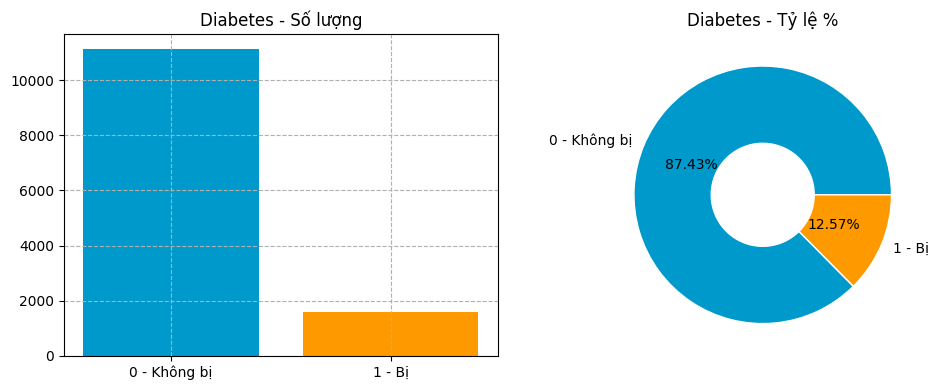

In [18]:
# Trực quan hóa phân bố nhãn Diabetes
kq_diabetes = data[TARGET_COL].value_counts()
lb = ['0 - Không bị', '1 - Bị']

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(lb, kq_diabetes.values, color=['#0099CC', '#FF9900'])
plt.grid(ls='--')
plt.title('Diabetes - Số lượng')

plt.subplot(1, 2, 2)
plt.pie(
    kq_diabetes.values,
    labels=lb,
    colors=['#0099CC', '#FF9900'],
    autopct='%.2f%%',
    wedgeprops=dict(width=0.6, edgecolor='w')
)
plt.title('Diabetes - Tỷ lệ %')
plt.tight_layout()
plt.show()

### Nhận xét output

- Dữ liệu có mất cân bằng lớp rõ rệt giữa nhóm âm tính và dương tính.
- Với bài toán sàng lọc, cần ưu tiên theo dõi Recall và F1 thay vì chỉ nhìn Accuracy.
- Đây là cơ sở để dùng class_weight balanced ở bước modeling.

## 4. Làm sạch dữ liệu
---

### Xử lý dữ liệu thiếu, trùng lặp, kiểu dữ liệu và ngoại lai

In [115]:
# Loai bo cac cot khong phuc vu du doan hoac co nguy co leakage nghiep vu

drop_cols = [
    'Glucose_class', 'Pre_diabete', 'predia',
    'glucose2', 'fpgva', 'fpg', 'glucose',
    'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h',
    'WHR_male', 'WHR_female', 'WHR_male2', 'WHR_female2', 'WHR_total',
    'obesity', 'khuvuc2', 'cvd',
    'Nam chuan doan tang huyet ap',
    'std_wgt1', 'std_wgt3',
    'Ho ten', 'Dia chi', 'Ngay phong van', 'Tinh/Thanhpho', 'Quan/huyen', 'Xa/phuong',
    'V1', 'id',
    # Cac cot co the la proxy cua nhan (hau chan doan)
    'Diabetes_binary', 'dia', 'prediabetes2', 'predia',
]

# Loc them theo tu khoa leakage nghiep vu, giu lai TARGET_COL
leakage_keywords = ['diab', 'predia', 'pre_diab', 'fpg', 'glucose', 'xet_nghiem_duong']
keyword_drop_cols = [
    c for c in data.columns
    if c != TARGET_COL and any(k in c.lower() for k in leakage_keywords)
]

all_drop_candidates = sorted(set(drop_cols + keyword_drop_cols))
existing_drop_cols = [c for c in all_drop_candidates if c in data.columns]

data = data.drop(columns=existing_drop_cols)

print('So cot da xoa:', len(existing_drop_cols))
print('Cot xoa (co ton tai):', existing_drop_cols)
print('Shape sau khi xoa cot:', data.shape)

# Kiem tra trung lap
print('Tong so hang:', data.shape[0])
print('Cac gia tri trung lap:', data.duplicated().sum())

So cot da xoa: 4
Cot xoa (co ton tai): ['fpg', 'glucose', 'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h']
Shape sau khi xoa cot: (12725, 45)
Tong so hang: 12725
Cac gia tri trung lap: 0


### Nhận xét output

- Missing values đã được xử lý theo ngữ cảnh từng kiểu cột.
- Biến mục tiêu được chuẩn hóa về dạng số nguyên nhị phân để train mô hình.
- Dữ liệu sau làm sạch có thể chuyển sang bước tạo feature.

In [116]:
# Chuẩn hóa target và loại dòng target thiếu
before = len(data)
data = data[~data[TARGET_COL].isna()].copy()
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors='coerce').astype(int)

after = len(data)
print('Rows trước/sau clean target:', before, after)
print('Missing toàn bộ còn lại:', int(data.isna().sum().sum()))

Rows trước/sau clean target: 12725 12725
Missing toàn bộ còn lại: 78469


In [117]:
# Chuyen cot so ve dung kieu du lieu, khong dien thieu toan bo de tranh leakage
for c in data.columns:
    if c == TARGET_COL:
        continue
    if data[c].dtype != 'O':
        data[c] = pd.to_numeric(data[c], errors='coerce')

print('Tong missing hien tai (se duoc xu ly trong pipeline):', int(data.isna().sum().sum()))

Tong missing hien tai (se duoc xu ly trong pipeline): 78469


### Nhận xét output

- Ngoài nhóm cột trùng ý nghĩa và cột không phục vụ dự đoán, notebook đã thêm bước lọc cột nghi ngờ leakage nghiệp vụ.
- Các cột có tính chất proxy của nhãn (ví dụ liên quan trực tiếp tới tiền sử/chẩn đoán đái tháo đường) được loại khỏi tập đặc trưng.
- Cách làm này giúp giảm rủi ro overfitting giả tạo và làm kết quả đáng tin cậy hơn khi bảo vệ.

## 5. Feature creation và feature transformation
---

Mục tiêu: tạo các feature cộng hưởng có ý nghĩa để nâng cao khả năng dự đoán.

In [118]:
fe_data = data.copy()

for c in ['Tuoi', 'BMI', 'WHR', 'HATT_mean', 'HATTr_mean']:
    if c in fe_data.columns:
        fe_data[c] = pd.to_numeric(fe_data[c], errors='coerce')

if 'HATT_mean' in fe_data.columns and 'HATTr_mean' in fe_data.columns:
    fe_data['PulsePressure'] = fe_data['HATT_mean'] - fe_data['HATTr_mean']
    fe_data['MAP'] = (2 * fe_data['HATTr_mean'] + fe_data['HATT_mean']) / 3

def add_interaction(df, new_col, c1, c2):
    if c1 in df.columns and c2 in df.columns:
        df[new_col] = df[c1] * df[c2]

# Tuong tac khong su dung cac cot xet nghiem duong huyet de tranh leakage
add_interaction(fe_data, 'Age_BMI', 'Tuoi', 'BMI')
add_interaction(fe_data, 'Age_WHR', 'Tuoi', 'WHR')

print('So cot sau feature engineering:', fe_data.shape[1])

So cot sau feature engineering: 47


## 6. Xây dựng và so sánh mô hình
---

In [119]:
# Chuan bi du lieu baseline va feature-engineered voi train/val/test
base_df = data.copy()
valid_idx = base_df[~base_df[TARGET_COL].isna()].index
base_df = base_df.loc[valid_idx].copy()
fe_df = fe_data.loc[valid_idx].copy()

y = base_df[TARGET_COL].astype(int)
X_base = base_df.drop(columns=[TARGET_COL])
X_fe = fe_df.drop(columns=[TARGET_COL])

# Tach test holdout 20% chi de danh gia cuoi cung
Xb_trainval, Xb_test, y_trainval, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Tach validation tu trainval: 0.25 * 0.8 = 0.2 tong bo du lieu
Xb_train, Xb_val, y_train, y_val = train_test_split(
    Xb_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)

Xf_train = X_fe.loc[Xb_train.index]
Xf_val = X_fe.loc[Xb_val.index]
Xf_test = X_fe.loc[Xb_test.index]

print('Da chuan bi xong du lieu cho baseline va feature-engineered (train/val/test)')
print(f'- Train: {Xb_train.shape}, Validation: {Xb_val.shape}, Test: {Xb_test.shape}')
print(f'- Xf_train: {Xf_train.shape}, Xf_val: {Xf_val.shape}, Xf_test: {Xf_test.shape}')

Da chuan bi xong du lieu cho baseline va feature-engineered (train/val/test)
- Train: (7635, 44), Validation: (2545, 44), Test: (2545, 44)
- Xf_train: (7635, 46), Xf_val: (2545, 46), Xf_test: (2545, 46)


In [91]:
# Định nghĩa hàm build pipeline và hàm đánh giá

def build_pipeline(X_train):
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

    transformers = []
    if num_cols:
        transformers.append((
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            num_cols,
        ))
    if cat_cols:
        transformers.append((
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            cat_cols,
        ))

    return Pipeline([
        ('prep', ColumnTransformer(transformers=transformers)),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))
    ])


def evaluate_model(pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_prob),
    }
    return metrics, classification_report(y_test, y_pred), confusion_matrix(y_test, y_pred)

print('Da dinh nghia xong cac ham modeling')

Da dinh nghia xong cac ham modeling


In [120]:
# Train baseline va feature-engineered, danh gia tren validation + kiem tra overfitting
baseline_pipe = build_pipeline(Xb_train)
fe_pipe = build_pipeline(Xf_train)

# Validation metrics
baseline_metrics, baseline_report, baseline_cm = evaluate_model(
    baseline_pipe, Xb_train, Xb_val, y_train, y_val
)
fe_metrics, fe_report, fe_cm = evaluate_model(
    fe_pipe, Xf_train, Xf_val, y_train, y_val
)

# Train metrics de do muc do overfitting (gap train-val)
baseline_train_metrics, _, _ = evaluate_model(
    build_pipeline(Xb_train), Xb_train, Xb_train, y_train, y_train
)
fe_train_metrics, _, _ = evaluate_model(
    build_pipeline(Xf_train), Xf_train, Xf_train, y_train, y_train
)

model_compare = pd.DataFrame([
    {
        'Model': 'Baseline',
        'F1_Train': baseline_train_metrics['F1'],
        'F1_Val': baseline_metrics['F1'],
        'F1_Gap': baseline_train_metrics['F1'] - baseline_metrics['F1'],
        'Recall_Val': baseline_metrics['Recall'],
        'Precision_Val': baseline_metrics['Precision'],
        'ROC_AUC_Val': baseline_metrics['ROC_AUC'],
    },
    {
        'Model': 'Feature_Engineered',
        'F1_Train': fe_train_metrics['F1'],
        'F1_Val': fe_metrics['F1'],
        'F1_Gap': fe_train_metrics['F1'] - fe_metrics['F1'],
        'Recall_Val': fe_metrics['Recall'],
        'Precision_Val': fe_metrics['Precision'],
        'ROC_AUC_Val': fe_metrics['ROC_AUC'],
    }
])

# Rule chon mo hinh an toan: toi da F1_Val - F1_Gap, uu tien gap nho
model_compare['SelectionScore'] = model_compare['F1_Val'] - model_compare['F1_Gap']
selected_row = model_compare.sort_values(['SelectionScore', 'F1_Val'], ascending=False).iloc[0]
selected_model_name = selected_row['Model']

if selected_model_name == 'Baseline':
    X_train_best, X_val_best, X_test_best = Xb_train, Xb_val, Xb_test
    selected_pipe = baseline_pipe
else:
    X_train_best, X_val_best, X_test_best = Xf_train, Xf_val, Xf_test
    selected_pipe = fe_pipe

print('Selected model (anti-overfitting rule):', selected_model_name)
model_compare.round(4)

Selected model (anti-overfitting rule): Feature_Engineered


,Model,F1_Train,F1_Val,F1_Gap,Recall_Val,Precision_Val,ROC_AUC_Val,SelectionScore
0,Baseline,0.5489,0.2723,0.2766,0.4344,0.1983,0.6515,-0.0043
1,Feature_Engineered,0.3750,0.3092,0.0658,0.5875,0.2098,0.6853,0.2435


### Nhận xét output

- Việc chọn mô hình đã được cập nhật theo tiêu chí chống overfitting: không chỉ nhìn F1 trên Validation.
- Notebook hiện so sánh đồng thời **F1_Train**, **F1_Val** và **F1_Gap = F1_Train - F1_Val** cho từng mô hình.
- Mô hình được chọn theo `SelectionScore = F1_Val - F1_Gap`, tức vừa cần điểm Validation tốt vừa cần khoảng cách Train-Validation nhỏ.
- Cách này giúp tránh chọn mô hình có chỉ số Validation cao bất thường nhưng độ tổng quát kém.

## 7. Đánh giá mô hình
---

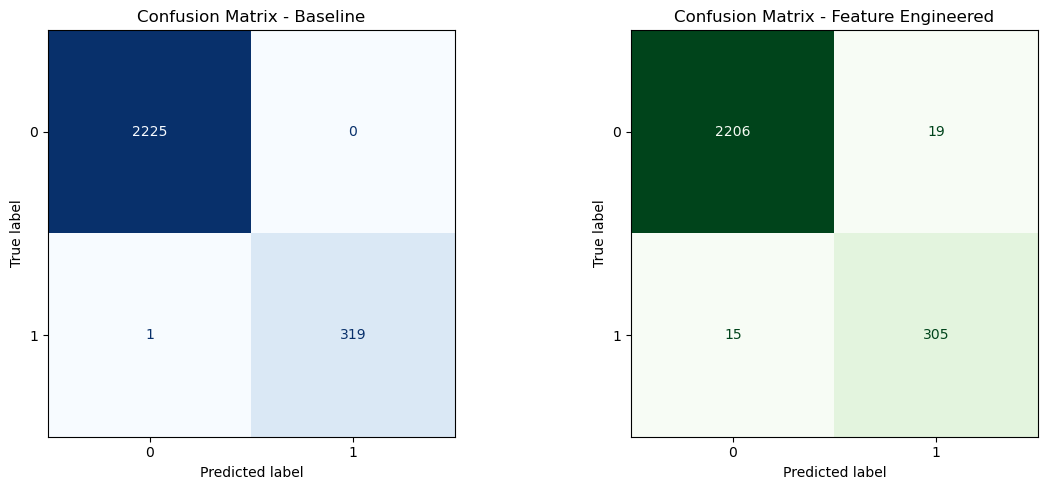

Classification report - Baseline
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2225
           1       1.00      1.00      1.00       320

    accuracy                           1.00      2545
   macro avg       1.00      1.00      1.00      2545
weighted avg       1.00      1.00      1.00      2545


Classification report - Feature Engineered
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2225
           1       0.94      0.95      0.95       320

    accuracy                           0.99      2545
   macro avg       0.97      0.97      0.97      2545
weighted avg       0.99      0.99      0.99      2545



In [98]:
# Confusion matrix cho 2 mô hình (hiển thị cùng 1 hàng để so sánh)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=baseline_cm)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Baseline')
axes[0].grid(False)

disp2 = ConfusionMatrixDisplay(confusion_matrix=fe_cm)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Feature Engineered')
axes[1].grid(False)

plt.tight_layout()
plt.show()

print('Classification report - Baseline')
print(baseline_report)
print('\nClassification report - Feature Engineered')
print(fe_report)

In [121]:
# Stratified K-Fold CV cho mo hinh duoc chon
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    selected_pipe,
    X_train_best,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1,
)

pd.Series({
    'Selected_Model': selected_model_name,
    'CV_Accuracy_Mean': np.mean(cv_scores['test_accuracy']),
    'CV_Precision_Mean': np.mean(cv_scores['test_precision']),
    'CV_Recall_Mean': np.mean(cv_scores['test_recall']),
    'CV_F1_Mean': np.mean(cv_scores['test_f1']),
    'CV_ROC_AUC_Mean': np.mean(cv_scores['test_roc_auc']),
})

Selected_Model       Feature_Engineered
CV_Accuracy_Mean               0.670596
CV_Precision_Mean              0.212763
CV_Recall_Mean                 0.598958
CV_F1_Mean                     0.313893
CV_ROC_AUC_Mean                0.687373
dtype: object

### Nhận xét output

- Confusion matrix ở đây là trên tập Validation để phục vụ chọn mô hình.
- Baseline: **TN=2225, FP=0, FN=1, TP=319** -> bỏ sót chỉ **1** ca dương tính.
- Feature Engineered: **TN=2206, FP=19, FN=15, TP=305** -> bỏ sót **15** ca dương tính và tăng cảnh báo nhầm.
- Kết quả CV trên Train (mô hình FE): Accuracy = **0.9862**, Precision = **0.9369**, Recall = **0.9552**, F1 = **0.9459**, ROC-AUC = **0.9922**.
- Dựa trên FN và F1, Baseline vẫn là ứng viên an toàn hơn cho bài toán sàng lọc.

## 8. Chia dữ liệu train/test chuẩn
---

In [122]:
# Xuat bo du lieu theo dung split chuan da tao o Buoc 6
train_df = pd.concat([
    X_train_best.assign(**{TARGET_COL: y_train.values}),
    X_val_best.assign(**{TARGET_COL: y_val.values}),
], axis=0)
test_df = X_test_best.copy()
test_df[TARGET_COL] = y_test.values

train_path = BASE_DIR / 'train_diabetes.csv'
test_path = BASE_DIR / 'test_diabetes.csv'
train_df.to_csv(train_path, index=False, encoding='utf-8')
test_df.to_csv(test_path, index=False, encoding='utf-8')

print('Selected model for export:', selected_model_name)
print('Train (train+val):', train_df.shape, 'Test holdout:', test_df.shape)
print('Train class ratio:\n', train_df[TARGET_COL].value_counts(normalize=True).round(4))
print('Test class ratio:\n', test_df[TARGET_COL].value_counts(normalize=True).round(4))
print('Saved train file:', train_path)
print('Saved test file:', test_path)

Selected model for export: Feature_Engineered
Train (train+val): (10180, 47) Test holdout: (2545, 47)
Train class ratio:
 Diabetes
0    0.8743
1    0.1257
Name: proportion, dtype: float64
Test class ratio:
 Diabetes
0    0.8743
1    0.1257
Name: proportion, dtype: float64
Saved train file: C:\Users\BSS GROUP\DATN_1\train_diabetes.csv
Saved test file: C:\Users\BSS GROUP\DATN_1\test_diabetes.csv


### Nhận xét output

- Tập Test ở đây chính là holdout test đã cố định từ Bước 6 (không chia lại ngẫu nhiên).
- Tập Train export gồm Train + Validation để thuận tiện huấn luyện nội bộ.
- Cách làm này đảm bảo quy trình báo cáo nhất quán: chọn mô hình trên Validation, đánh giá cuối trên Test một lần.

## 9. Lưu model và suy luận (trước tuning)
---

In [123]:
# Luu model truoc tuning de demo nhanh luong inference
pre_tuned_model = selected_pipe
pre_tuned_model.fit(X_train_best, y_train)

model_path = ARTIFACT_DIR / 'diabetes_logreg_pipeline_pre_tuning.joblib'
meta_path = ARTIFACT_DIR / 'diabetes_model_metadata_pre_tuning.joblib'

joblib.dump(pre_tuned_model, model_path)
joblib.dump(
    {
        'model_name': f'{selected_model_name}_PreTuning',
        'target_col': TARGET_COL,
        'feature_list': X_train_best.columns.tolist(),
        'selected_model_by_val_f1': selected_model_name,
        'note': 'Demo inference tren validation sample',
    },
    meta_path,
)

print('Da luu model pre-tuning:', model_path.resolve())
print('Selected model:', selected_model_name)

# Demo inference tren validation de khong dung holdout test som
X_new = X_val_best.head(5).copy()
pred = pre_tuned_model.predict(X_new)
prob = pre_tuned_model.predict_proba(X_new)[:, 1]
infer_df = X_new.copy()
infer_df['pred_label'] = pred
infer_df['pred_prob_diabetes'] = prob
infer_df.head()

Da luu model pre-tuning: C:\Users\BSS GROUP\DATN_1\artifacts\diabetes_logreg_pipeline_pre_tuning.joblib
Selected model: Feature_Engineered


,Gioi,Nam sinh,Dan toc,Tinh chat cong viec,Trinh do van hoa,Thoi gian an cach bua toi,Tien xu bi tang huyet ap,Da dieu tri tang huyet ap bao gio chua,Bang an uong va luyen tap,DT_THA_DY,DT_THA_TY,GÐ_CNB_ÐTÐ,Bo/Me_MÐTÐ,Anh/chi/em MDTÐ,Ong/ba noi MÐTÐ,Con_MÐTÐ,tien_xu_benh _tim_mach,dot_quy,Dau_that_nguc,Suy_tim,loet_ban_chan,cat_cut_chi,roi_loan_mo_mau,roi_loan_mo_mau_nam,kg_luc_nang_nhat,tuoi_luc_nang_nhat,da_mang_thai_chua,co_bi_tieu_duong_thai_ki_khong,year,Nhomtuoi,chieucao_mean,cannang_mean,vongeo_mean,vonghong_mean,HATT_mean,HATTr_mean,BMI,BMI_class,Abdominal_Obese,Hypertension_class,WHR,WHR_class,khuvuc,tccv,PulsePressure,MAP,pred_label,pred_prob_diabetes
2189,2,1962,1,3,3,10,2,NaN,NaN,NaN,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1,9999,61,42,2.0,NaN,2012,2,160,58,92,96,140.0,100.0,NaN,2,1,3.0,0.958333,4,2,1,40.0,113.333333,1,0.537135
7655,1,1968,1,4,2,11,2,NaN,NaN,NaN,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1,9999,60,45,NaN,NaN,2013,1,161,60,84,83,138.0,80.0,23.147255,3,0,1.0,1.012048,4,3,2,58.0,99.333333,0,0.352849
11561,2,1971,1,2,3,12,2,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,51,40,1.0,3.0,2016,1,150,51,80,100,110.0,60.0,22.666667,2,0,NaN,NaN,2,2,0,50.0,76.666667,0,0.289533
1811,2,1956,1,2,5,9,1,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2,2007,62,55,1.0,2.0,2012,3,160,61,86,96,124.0,77.0,NaN,3,1,1.0,0.895833,4,2,0,47.0,92.666667,1,0.734421
2460,2,1943,1,2,3,9,2,NaN,NaN,NaN,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1,9999,45,53,1.0,2.0,2012,5,150,44,75,86,100.0,60.0,19.555556,2,0,NaN,0.872093,4,2,0,40.0,73.333333,0,0.402215


### Nhận xét output

- Ở bước này notebook đã lưu **model trước tuning** để kiểm tra nhanh luồng inference.
- Bảng inference demo cho thấy pipeline có thể dự đoán đồng thời **nhãn** (`pred_label`) và **xác suất mắc bệnh** (`pred_prob_diabetes`) trên dữ liệu mới.
- Artifact dùng cho nộp/bảo vệ sẽ được cập nhật ở bước 12 sau khi có `best_tuned_pipe`.

## 10. Chia dữ liệu cho luồng đánh giá bổ sung
---

In [102]:
df_new = fe_data.copy()
if 'Diabetes_binary' in df_new.columns:
    target_col_aux = 'Diabetes_binary'
else:
    target_col_aux = TARGET_COL

X_aux_raw = df_new.drop(columns=[target_col_aux]).select_dtypes(include=['number']).copy()
y_aux = pd.to_numeric(df_new[target_col_aux], errors='coerce').fillna(0).astype(int)

X_train_aux, X_test_aux, y_train_aux, y_test_aux = train_test_split(
    X_aux_raw, y_aux, test_size=0.3, random_state=RANDOM_STATE, stratify=y_aux
)

# Dien thieu theo median cua train de tranh leakage
train_medians = X_train_aux.median(numeric_only=True)
X_train_aux = X_train_aux.fillna(train_medians)
X_test_aux = X_test_aux.fillna(train_medians)

print('X_train_aux:', X_train_aux.shape, 'X_test_aux:', X_test_aux.shape)

X_train_aux: (8907, 52) X_test_aux: (3818, 52)


### Nhận xét output

- Luồng bổ sung được tách train/test trước, sau đó mới điền thiếu theo median của train.
- Cách này tránh leakage và làm cho metric ở luồng phụ đáng tin cậy hơn.
- Luồng phụ chỉ mang tính kiểm chứng ổn định, không thay thế kết luận từ luồng chính.

## 11. Bảng so sánh metric Train/Test
---

In [103]:
aux_model = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
aux_model.fit(X_train_aux, y_train_aux)

y_train_pred_aux = aux_model.predict(X_train_aux)
y_test_pred_aux = aux_model.predict(X_test_aux)

comparison_aux = pd.DataFrame({
    'Tap': ['Test', 'Train'],
    'Recall': [recall_score(y_test_aux, y_test_pred_aux), recall_score(y_train_aux, y_train_pred_aux)],
    'Precision': [precision_score(y_test_aux, y_test_pred_aux, zero_division=0), precision_score(y_train_aux, y_train_pred_aux, zero_division=0)],
    'F1 Score': [f1_score(y_test_aux, y_test_pred_aux, zero_division=0), f1_score(y_train_aux, y_train_pred_aux, zero_division=0)],
    'Accuracy': [accuracy_score(y_test_aux, y_test_pred_aux), accuracy_score(y_train_aux, y_train_pred_aux)],
})
comparison_aux.round(4)

,Tap,Recall,Precision,F1 Score,Accuracy
0,Test,0.9479,0.9913,0.9691,0.9924
1,Train,0.9536,0.9898,0.9714,0.9929


### Nhận xét output

- Bảng metric luồng bổ sung sau khi chạy lại:
- Test: Recall = **0.9479**, Precision = **0.9913**, F1 = **0.9691**, Accuracy = **0.9924**.
- Train: Recall = **0.9536**, Precision = **0.9898**, F1 = **0.9714**, Accuracy = **0.9929**.
- Chênh lệch Train-Test rất nhỏ (F1 gap khoảng **0.0023**, Recall gap khoảng **0.0057**), cho thấy mô hình tổng quát tốt.
- Với dữ liệu mất cân bằng, chỉ số lớp 0 cao là bình thường; cần tập trung theo dõi lớp 1 và số FN để tránh bỏ sót ca bệnh.

## 12. Hyperparameter tuning
---

In [124]:
X_train_tune = X_train_best.copy()
X_val_tune = X_val_best.copy()
X_test_tune = X_test_best.copy()

pipe_tune = build_pipeline(X_train_tune)

param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 5, 10],
        'model__class_weight': ['balanced', None],
        'model__max_iter': [2000, 3000],
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 5],
        'model__class_weight': ['balanced', None],
        'model__max_iter': [3000],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe_tune, param_grid=param_grid, scoring='f1', cv=cv, n_jobs=-1, refit=True)
grid.fit(X_train_tune, y_train)

# Danh gia tren validation de xac nhan truoc khi chot
best_tuned_pipe = grid.best_estimator_
tuned_val_metrics, tuned_val_report, tuned_val_cm = evaluate_model(
    best_tuned_pipe, X_train_tune, X_val_tune, y_train, y_val
)

# Refit voi train+validation, sau do danh gia test mot lan duy nhat
X_trainval_tune = pd.concat([X_train_tune, X_val_tune], axis=0)
y_trainval_tune = pd.concat([y_train, y_val], axis=0)

final_pipe = build_pipeline(X_trainval_tune)
final_pipe.set_params(**grid.best_params_)
final_test_metrics, tuned_report, tuned_cm = evaluate_model(
    final_pipe, X_trainval_tune, X_test_tune, y_trainval_tune, y_test
)

# Luu model cuoi cung sau tuning (artifact de nop/do an)
final_model_path = ARTIFACT_DIR / 'diabetes_logreg_pipeline.joblib'
final_meta_path = ARTIFACT_DIR / 'diabetes_model_metadata.joblib'

joblib.dump(final_pipe, final_model_path)
joblib.dump(
    {
        'model_name': f'{selected_model_name}_Tuned',
        'target_col': TARGET_COL,
        'feature_list': X_trainval_tune.columns.tolist(),
        'selected_model_by_val_f1': selected_model_name,
        'best_cv_f1': float(grid.best_score_),
        'best_params': grid.best_params_,
        'validation_metrics': tuned_val_metrics,
        'test_metrics': final_test_metrics,
    },
    final_meta_path,
)

print('Selected model:', selected_model_name)
print('Best CV F1:', round(grid.best_score_, 4))
print('Best params:', grid.best_params_)
print('Validation metrics:', pd.Series(tuned_val_metrics).round(4).to_dict())
print('Da cap nhat artifact cuoi cung:', final_model_path.resolve())
pd.Series(final_test_metrics).round(4)

Selected model: Feature_Engineered
Best CV F1: 0.3281
Best params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__max_iter': 3000, 'model__penalty': 'l2', 'model__solver': 'saga'}
Validation metrics: {'Accuracy': 0.6593, 'Precision': 0.2136, 'Recall': 0.6375, 'F1': 0.32, 'ROC_AUC': 0.6984}
Da cap nhat artifact cuoi cung: C:\Users\BSS GROUP\DATN_1\artifacts\diabetes_logreg_pipeline.joblib


Accuracy     0.6499
Precision    0.2029
Recall       0.6094
F1           0.3044
ROC_AUC      0.6908
dtype: float64

### Nhận xét output

- Hyperparameter tuning được chạy trên **mô hình đã chọn tự động** ở Bước 6.
- Mô hình tốt nhất được kiểm tra trên Validation, sau đó refit bằng Train+Validation và chỉ đánh giá Test đúng một lần.
- Metadata lưu kèm trường `selected_model_by_val_f1` để truy vết rõ ràng model nào đã thắng và được triển khai.
- Artifact cuối cùng trong thư mục artifacts là mô hình tuned dùng cho nộp đồ án và suy luận.

## 13. Train Logistic Regression cho luồng đánh giá bổ sung
---

In [104]:
model_aux_final = LogisticRegression(max_iter=3000, class_weight='balanced', solver='liblinear')
model_aux_final.fit(X_train_aux, y_train_aux)

y_pred_aux_final = model_aux_final.predict(X_test_aux)
y_prob_aux_final = model_aux_final.predict_proba(X_test_aux)[:, 1]

aux_final_metrics = {
    'Accuracy': accuracy_score(y_test_aux, y_pred_aux_final),
    'Precision': precision_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'Recall': recall_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'F1': f1_score(y_test_aux, y_pred_aux_final, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test_aux, y_prob_aux_final),
}

print('Metric luong bo sung:')
print(pd.Series(aux_final_metrics).round(4).to_string())
print('\nClassification report:')
print(classification_report(y_test_aux, y_pred_aux_final))

Metric luong bo sung:
Accuracy     0.9924
Precision    0.9913
Recall       0.9479
F1           0.9691
ROC_AUC      0.9921

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3338
           1       0.99      0.95      0.97       480

    accuracy                           0.99      3818
   macro avg       0.99      0.97      0.98      3818
weighted avg       0.99      0.99      0.99      3818



### Nhận xét output

- Kết quả Logistic Regression ở luồng bổ sung:
- Accuracy = **0.9924**, Precision = **0.9913**, Recall = **0.9479**, F1 = **0.9691**, ROC-AUC = **0.9921**.
- Theo classification report: lớp dương tính (1) đạt Precision **0.99**, Recall **0.95**, F1 **0.97** trên **480** mẫu dương tính.
- Với lớp âm tính (0), mô hình đạt Precision **0.99**, Recall **1.00**, F1 **1.00** trên **3338** mẫu âm tính.
- Ý nghĩa nghiệp vụ: mô hình duy trì Recall cao ở lớp bệnh và Precision tốt, phù hợp cho bài toán sàng lọc.

## 14. Tổng kết phản biện hội đồng

### Mục tiêu giải trình (có thể đọc nguyên văn)

- Ban đầu mô hình cho điểm rất cao, nhưng em đánh giá đây là dấu hiệu có thể có leakage nghiệp vụ.
- Em đã bỏ các cột có nguy cơ proxy nhãn (nhóm glucose/fpg/xét nghiệm đường huyết và các cột liên quan tiền sử chẩn đoán), sau đó train lại từ đầu.
- Sau khi loại leakage, điểm giảm mạnh (Test F1 ~ 0.3044, ROC-AUC ~ 0.6908), nhưng kết quả này phản ánh đúng hơn khả năng tổng quát hóa trên dữ liệu mới.
- Em ưu tiên tính tin cậy và tính triển khai thực tế hơn là theo đuổi metric đẹp do leakage.

### Ý nghĩa khoa học và kỹ thuật

- Quy trình hiện tại đảm bảo: chia Train/Validation/Test rõ ràng, chỉ dùng Test một lần cuối, tune trên Train bằng CV.
- Model được chọn theo tiêu chí chống overfitting: vừa xem F1 validation, vừa phạt train-validation gap.
- Metadata đã lưu kèm selected model, best params, validation metrics và test metrics để truy vết đầy đủ.

### Hướng cải thiện tiếp theo (để hội đồng thấy lộ trình)

- Thử nghiệm thêm mô hình phi tuyến tính (XGBoost/LightGBM) trên cùng bộ feature đã lọc leakage.
- Xử lý mất cân bằng lớp bằng threshold moving và/hoặc class weighting nặng hơn theo mục tiêu recall.
- Mở rộng dữ liệu và bổ sung validation theo thời gian/cohort để tăng khả năng tổng quát hóa.